  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                   Master          Average  

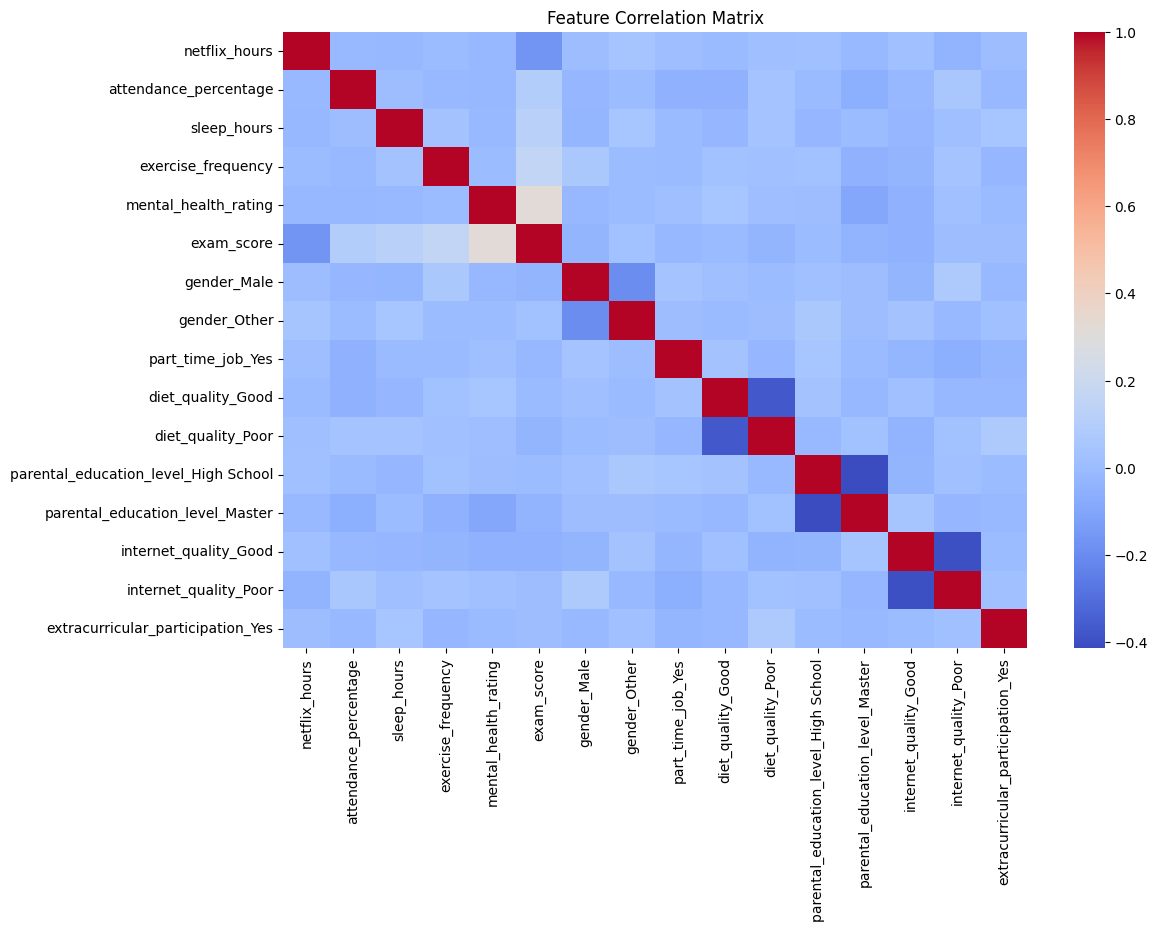

R² Score: 0.09201220558332879
MSE: 246.4578890494507


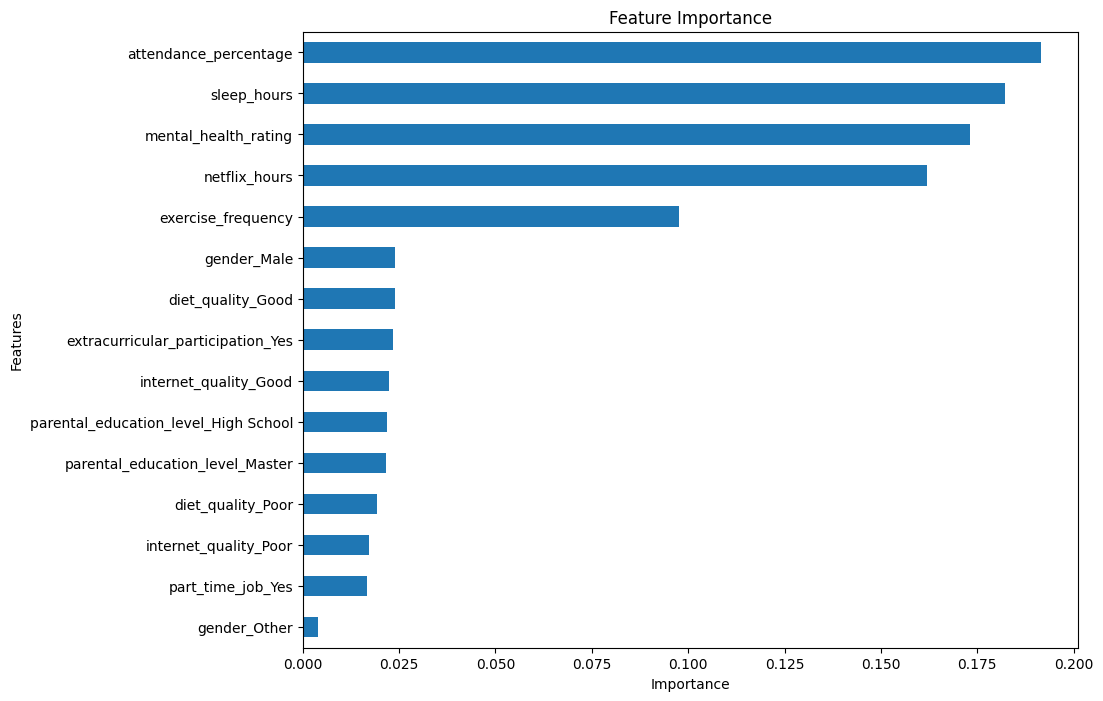

In [2]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("C:/Users/BALAM/Downloads/student_habits_performance.csv")

# Preview data
print(df.head())
print(df.info())

# Drop irrelevant or high-cardinality columns
df.drop(['student_id', 'age', 'study_hours_per_day', 'social_media_hours'], axis=1, inplace=True)

# Handle missing values
df.dropna(inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()

# Define features and target
X = df.drop(['exam_score'], axis=1)
y = df['exam_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8), title='Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


Text(0.5, 1.0, 'attendance by Academic Performance')

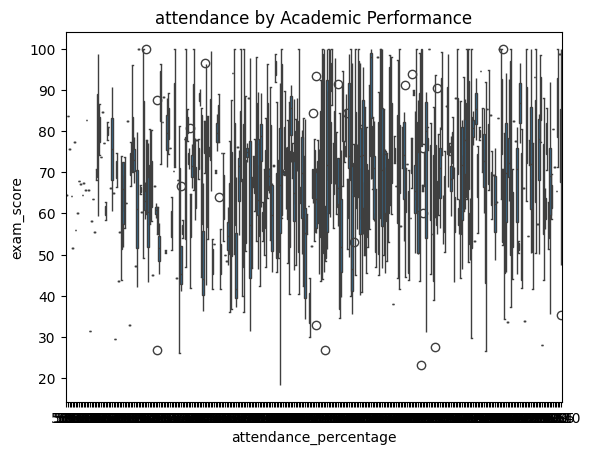

In [7]:
sns.boxplot(x='attendance_percentage', y='exam_score', data=df)
plt.title('attendance by Academic Performance')



Text(0.5, 1.0, 'Sleep Hours Distribution by Performance')

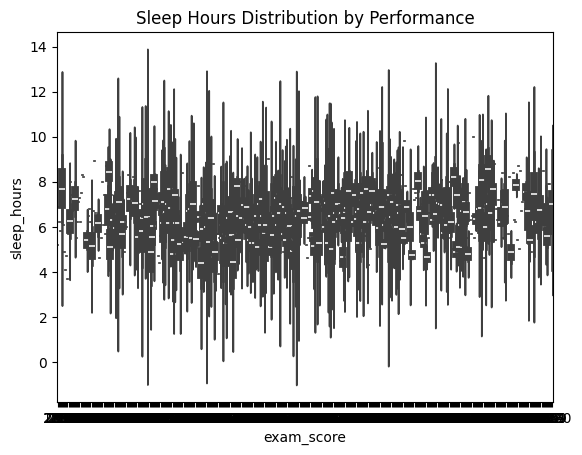

In [8]:
sns.violinplot(x='exam_score', y='sleep_hours', data=df)
plt.title('Sleep Hours Distribution by Performance')


Text(0.5, 1.0, 'Mental Hearlth Rating and Exam Score')

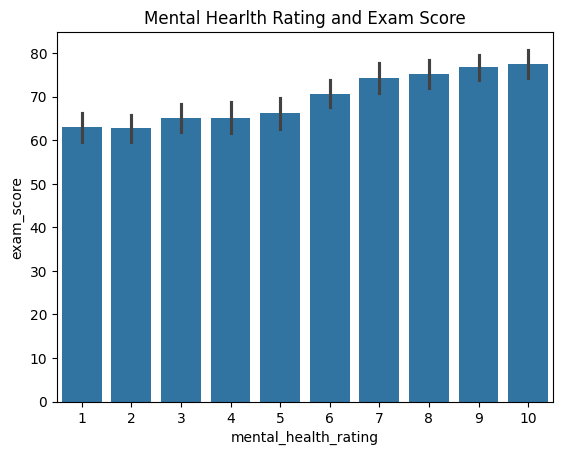

In [11]:
sns.barplot(x='mental_health_rating', y='exam_score', data=df)
plt.title('Mental Hearlth Rating and Exam Score')


(1000, 16)
Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          

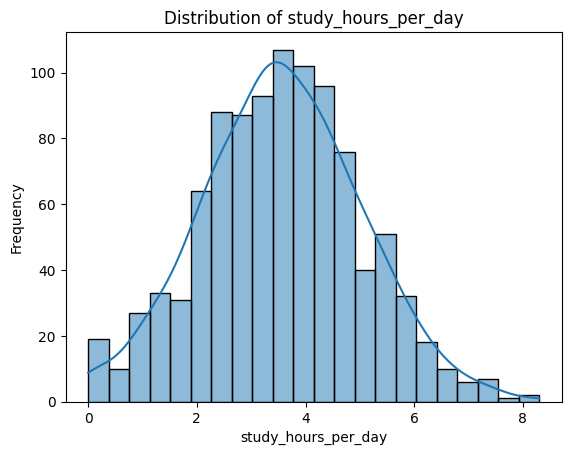

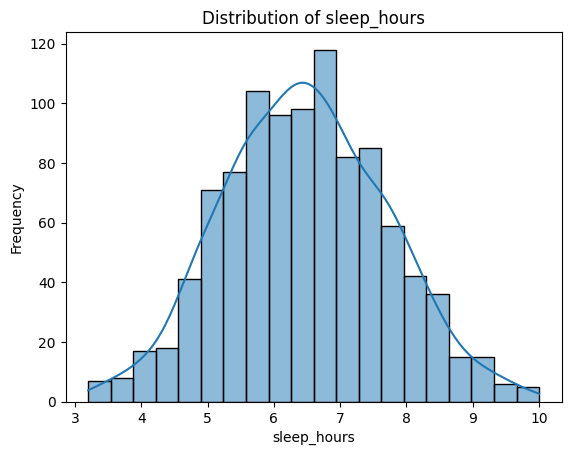

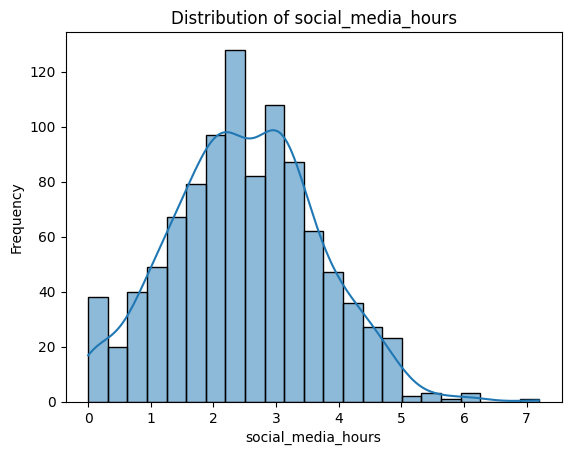

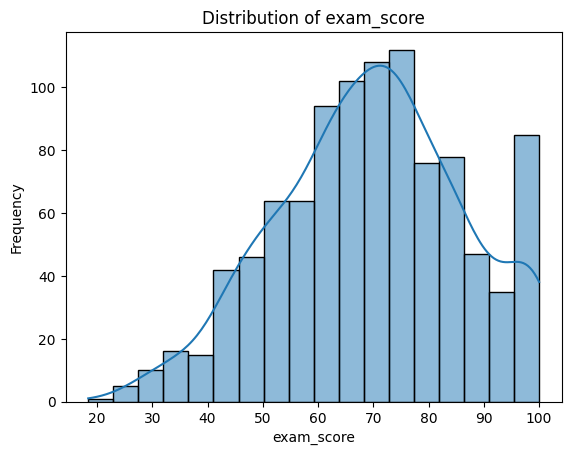

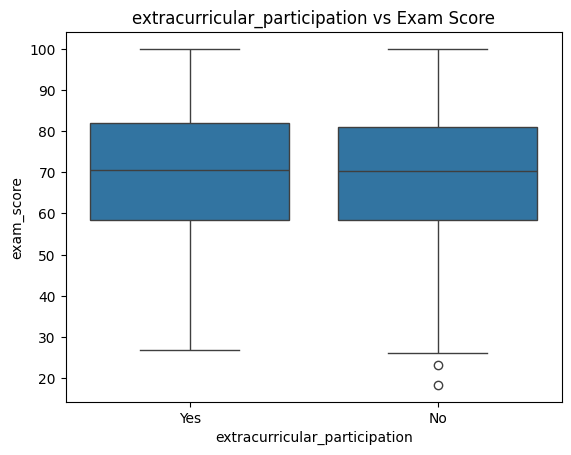

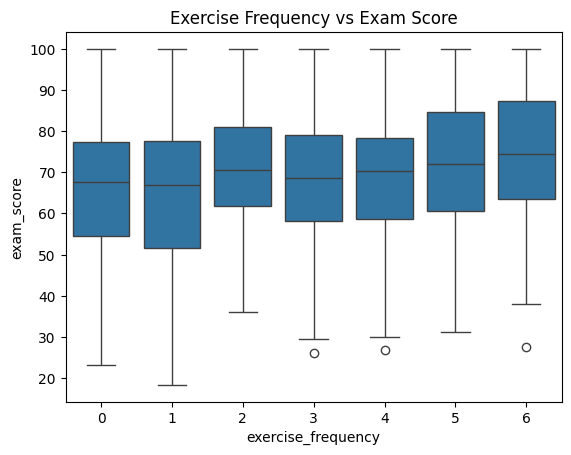

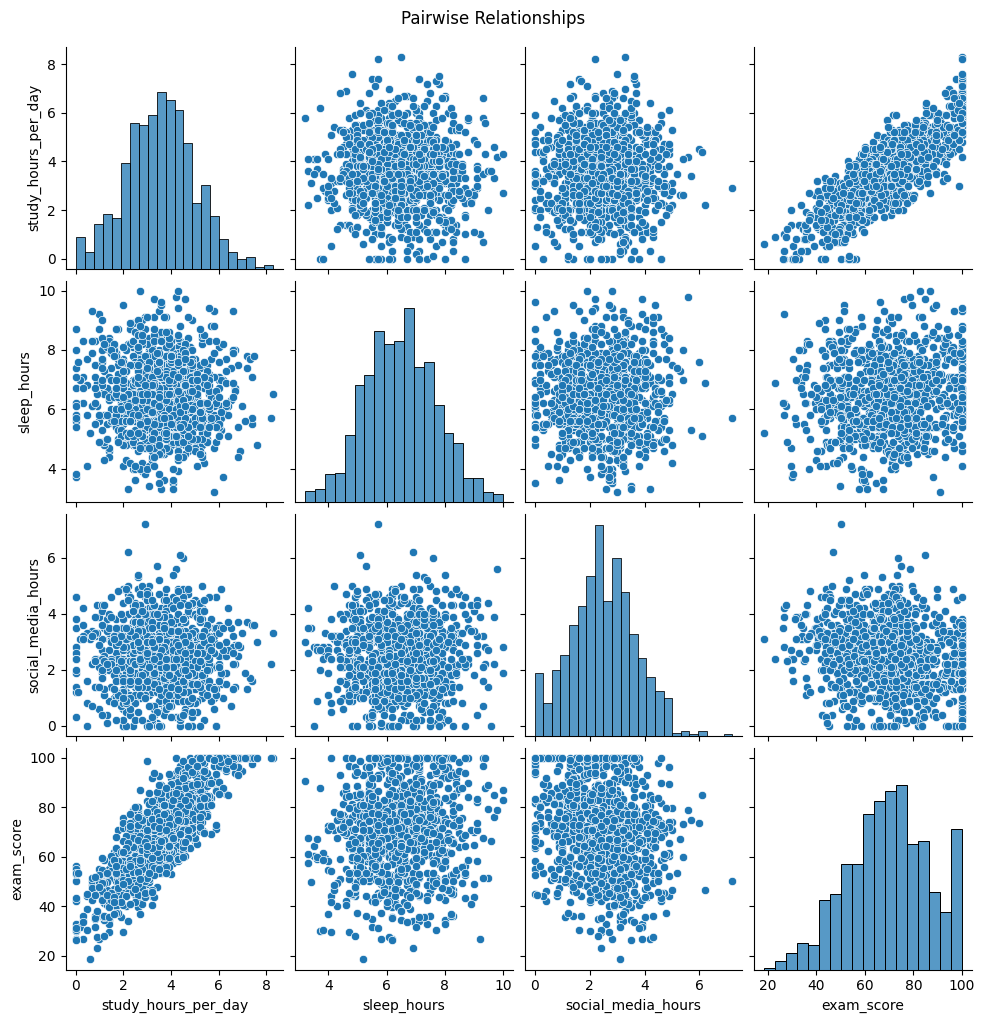

Average Exam Score by exercise_frequency:
 exercise_frequency
0    66.375000
1    65.805479
2    70.459016
3    68.379085
4    68.734328
5    72.706040
6    74.567763
Name: exam_score, dtype: float64


In [19]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load dataset

# Load dataset
df = pd.read_csv("C:/Users/BALAM/Downloads/student_habits_performance.csv")
print(df.shape)
print(df.columns)
print(df.head())

# 3. Summary statistics
print(df.describe(include='all'))

# 4. Missing values
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0])

# 5. Data types and unique values
print(df.dtypes)
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

# 6. Distribution plots
numeric_cols = ['study_hours_per_day', 'sleep_hours', 'social_media_hours', 'exam_score']
for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# 7. Boxplots for habits vs performance
sns.boxplot(x='extracurricular_participation', y='exam_score', data=df)
plt.title('extracurricular_participation vs Exam Score')
plt.show()

sns.boxplot(x='exercise_frequency', y='exam_score', data=df)
plt.title('Exercise Frequency vs Exam Score')
plt.show()

# 8. Pairplot for selected features
selected = ['study_hours_per_day', 'sleep_hours', 'social_media_hours', 'exam_score']
sns.pairplot(df[selected])
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

# 9. Grouped means
grouped = df.groupby('exercise_frequency')['exam_score'].mean()
print("Average Exam Score by exercise_frequency:\n", grouped)
